# Text Analytics Coursework

### Customer Support Ticket EDA
This section explored the dataset to understand the nature of customer issues and inform preprocessing and modelling decisions. 
The analysis focuses on identifying common patterns in customer complaints and evaluating data quality. 

In [1]:
# Data Exploration Notebook : to understand customer issues 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
nltk.download('stopwords', quiet=True)


True

In [2]:
# Load the data
df = pd.read_csv("customer_support_tickets.csv")

# Inspect data
print(df.head())
print(df.info())
print(df.describe())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [3]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


The missing values were examined to assess data quality. 
The dataset contains missing values, which could affect analysis and ranking later.

In [4]:
# Clean text
custom_noise = {'productpurchased', 'issue', 'please', 'assist', 'ive', 'problem', 'software', 'im', 'would', 'tried', 'using', 'need', 'product', 'issue', 'please', 'could'}
stop_words = set(stopwords.words('english')).union(custom_noise)

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove stop words and custom noise
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

#Apply Cleaning 
df["clean_text"] = df["Ticket Description"].apply(preprocess_text)

## Text Preprocessing
Text preprocessing was applied to the "Ticket Description" to prepare the data analysis. This included converting text to lowercase, removing numbers and punctuation, and eliminating stopwords and domain-specific noise. This process ensures that only meaningful words are retained, improving the quality of text analysis. 

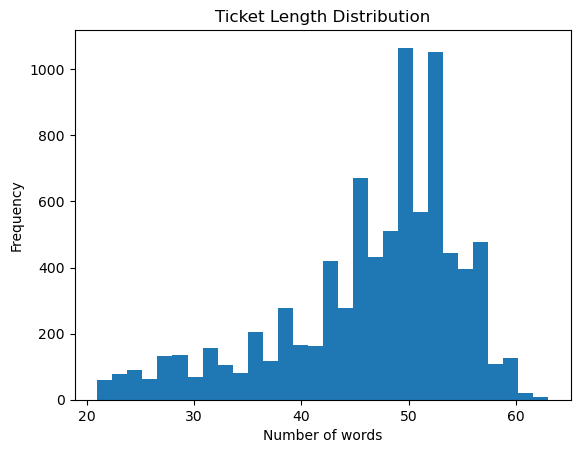

In [11]:
# Ticket length distribution
df["length_words"] = df["Ticket Description"].apply(lambda x: len(str(x).split()))
plt.hist(df["length_words"], bins=30)
plt.title("Ticket Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

## Ticket length distribution 
The distribution of ticket length was analysed to understand how detailed customer complaints are. 
The distribution shows that most customer support tickets contain a moderate number of words, suggesting that customers generally provide sufficiently detailed issues, which is useful for text analysis. 

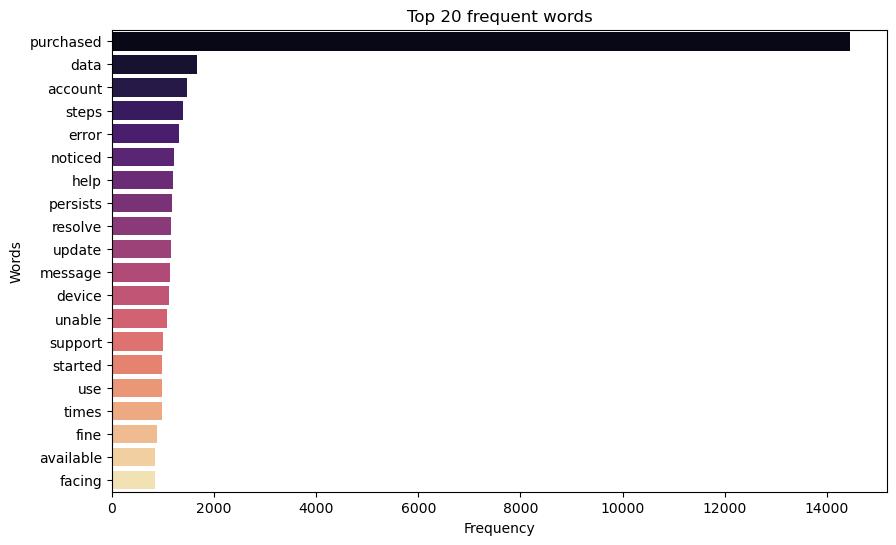

In [6]:
all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words).most_common(20)
# Plot
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


## Most frequent words
The most frequent words were identified after preprocessing to understand the main themes of customer complaints. 
The most common words were purchased, data, and account, suggesting that customer issues are primarily related to products and account access.

In [7]:
# Vectorise cleaned text
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
x = vectorizer.fit_transform(df['clean_text'])

### Text Vectorisation
The clean data was converted into numerical format using IF-IDF vectorisation. This allows for processing the text data by representing each document as a vector of features. 

In [8]:
# A quick K-Means 
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(x)    

### K-Means clustering
KMean clustering was applied to group similar customer support tickets based on their textual content. This help identify underlying patterns and categories of customer issues. 

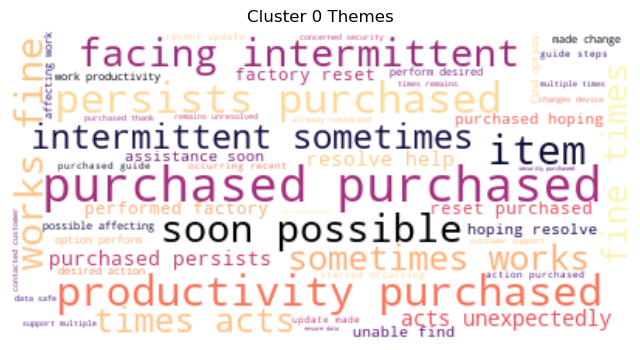

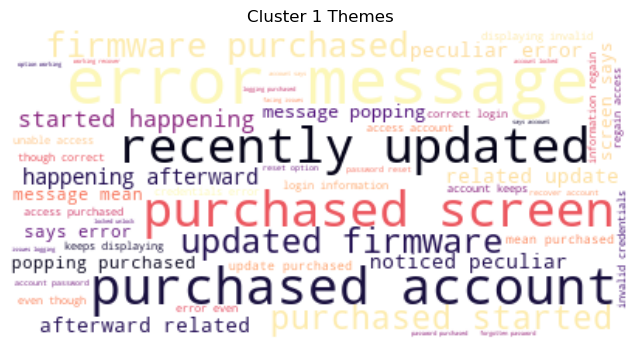

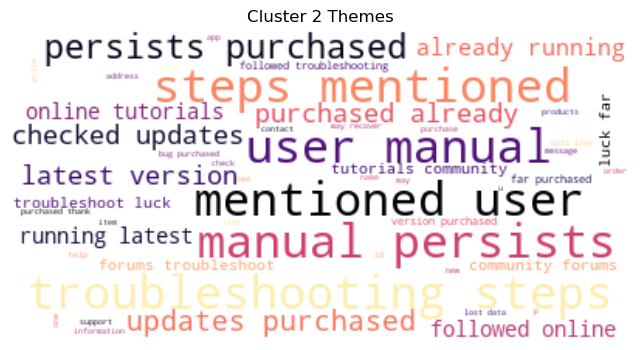

In [9]:
# Word clouds for each cluster
for i in range(num_clusters):
    cluster_text = " ".join(df[df['cluster'] == i]['clean_text'])

    # Generate word cloud
    wordcloud = WordCloud(background_color='white', colormap='magma', max_words=50).generate(cluster_text)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Cluster {i} Themes')
    plt.axis('off')
    plt.show()

## Cluster Word cloud
Word clouds were generated for each cluster to visualise the most important words within each group. 
Cluster 0 appears to represent purchese related issues
* To Do : interpretation